# UNet UQ for a 2D Diffusion Operator

This notebook trains `UNet2D` on a transient 2D diffusion problem,

$$
\partial_t u = \kappa \Delta u,
$$

mapping an initial field $u_0(x,y)$ to a final field $u(x,y,T)$. Because the
heat equation has an exact spectral solution on a periodic grid, we can build a
clean scientific-ML benchmark and focus on uncertainty behavior.

Primary references:

- Ronneberger et al. (2015), *U-Net: Convolutional Networks for Biomedical Image Segmentation*
- Gal & Ghahramani (2016), *Dropout as a Bayesian Approximation*


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import MCDropoutWrapper
from deepuq.models import UNet2D

torch.manual_seed(5)
np.random.seed(5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


In [2]:
config = {
    'n_train': 192,
    'n_val': 48,
    'n_test': 48,
    'n_ood': 48,
    'grid_size': 32,
    'kappa': 0.03,
    'final_time': 0.08,
    'epochs': 120,
    'batch_size': 8,
    'lr': 2e-3,
}

x = torch.linspace(0.0, 1.0, config['grid_size'] + 1)[:-1]
X, Y = torch.meshgrid(x, x, indexing='ij')


def random_field(n_samples, *, ood=False):
    fields = []
    freq_cap = 3 if not ood else 6
    amp_scale = 1.0 if not ood else 1.6
    for _ in range(n_samples):
        field = torch.zeros_like(X)
        for kx in range(1, freq_cap + 1):
            for ky in range(1, freq_cap + 1):
                coeff = amp_scale * torch.randn(1).item() / (kx + ky)
                phase_x = 2 * math.pi * torch.rand(1).item()
                phase_y = 2 * math.pi * torch.rand(1).item()
                field = field + coeff * torch.cos(2 * math.pi * kx * X + phase_x) * torch.cos(2 * math.pi * ky * Y + phase_y)
        if ood:
            cx, cy = torch.rand(2).tolist()
            field = field + 1.3 * torch.exp(-90.0 * ((X - cx) ** 2 + (Y - cy) ** 2))
        fields.append(field)
    return torch.stack(fields, dim=0)


def heat_solve(initial):
    u_hat = torch.fft.fftn(initial, dim=(-2, -1))
    freqs = torch.fft.fftfreq(initial.shape[-1], d=1.0 / initial.shape[-1])
    kx, ky = torch.meshgrid(freqs, freqs, indexing='ij')
    decay = torch.exp(-4.0 * math.pi**2 * config['kappa'] * config['final_time'] * (kx**2 + ky**2))
    return torch.fft.ifftn(u_hat * decay, dim=(-2, -1)).real


def build_dataset(n_samples, *, ood=False):
    init = random_field(n_samples, ood=ood)
    final = heat_solve(init)
    return init.unsqueeze(1), final.unsqueeze(1)

train_x, train_y = build_dataset(config['n_train'])
val_x, val_y = build_dataset(config['n_val'])
test_x, test_y = build_dataset(config['n_test'])
ood_x, ood_y = build_dataset(config['n_ood'], ood=True)

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(TensorDataset(val_x, val_y), batch_size=config['batch_size'])


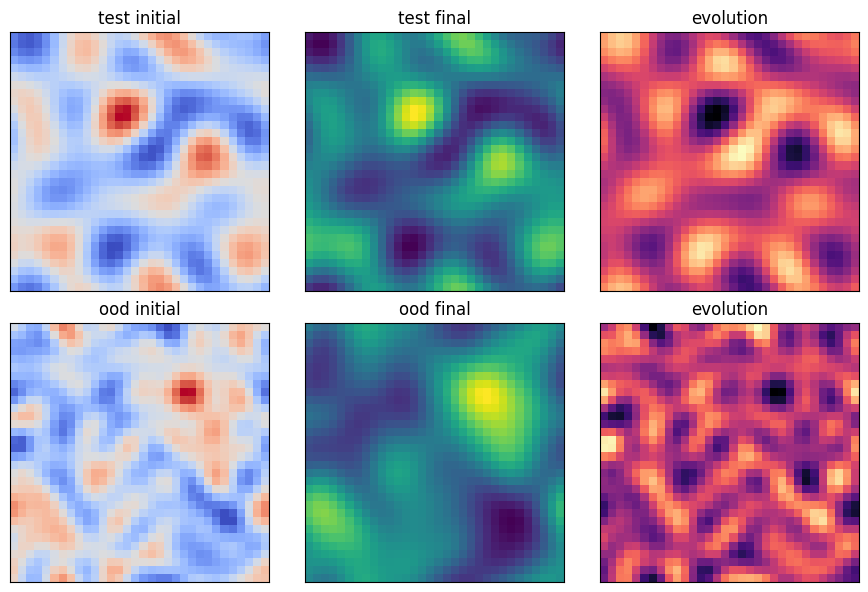

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row, (x_set, y_set, label) in enumerate([(test_x, test_y, 'test'), (ood_x, ood_y, 'ood')]):
    axes[row, 0].imshow(x_set[0, 0], cmap='coolwarm')
    axes[row, 0].set_title(f'{label} initial')
    axes[row, 1].imshow(y_set[0, 0], cmap='viridis')
    axes[row, 1].set_title(f'{label} final')
    axes[row, 2].imshow((y_set[0, 0] - x_set[0, 0]), cmap='magma')
    axes[row, 2].set_title('evolution')
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


In [4]:
model = UNet2D(in_channels=1, out_channels=1, base_channels=16, dropout_p=0.1).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-4)
history = {'train': [], 'val': []}
for _ in range(config['epochs']):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)
        loss = torch.nn.functional.mse_loss(model(xb), yb)
        loss.backward()
        opt.step()
        train_loss += loss.item() * xb.size(0)
    history['train'].append(train_loss / len(train_loader.dataset))
    model.eval()
    val_loss = 0.0
    with torch.inference_mode():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += torch.nn.functional.mse_loss(model(xb), yb).item() * xb.size(0)
    history['val'].append(val_loss / len(val_loader.dataset))


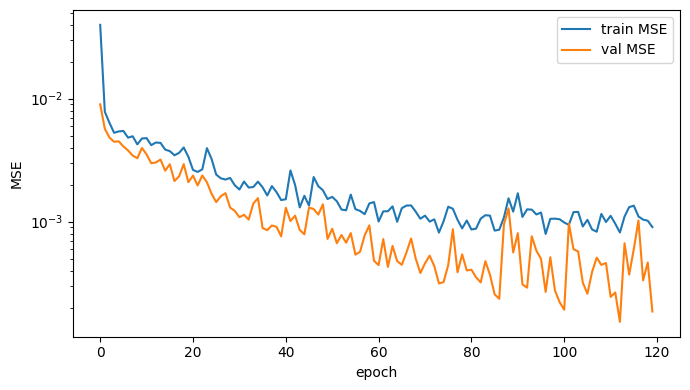

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(history['train'], label='train MSE')
plt.plot(history['val'], label='val MSE')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
mc = MCDropoutWrapper(model, n_mc=20, apply_softmax=False)
with torch.inference_mode():
    pred_test = model(test_x.to(device)).cpu()
    pred_ood = model(ood_x.to(device)).cpu()
    uq_test = mc.predict_uq(test_x.to(device))
    uq_ood = mc.predict_uq(ood_x.to(device))

rmse_test = torch.mean((pred_test - test_y) ** 2).sqrt().item()
rmse_ood = torch.mean((pred_ood - ood_y) ** 2).sqrt().item()
print({'test_rmse': rmse_test, 'ood_rmse': rmse_ood})


{'test_rmse': 0.01314789243042469, 'ood_rmse': 0.17786628007888794}


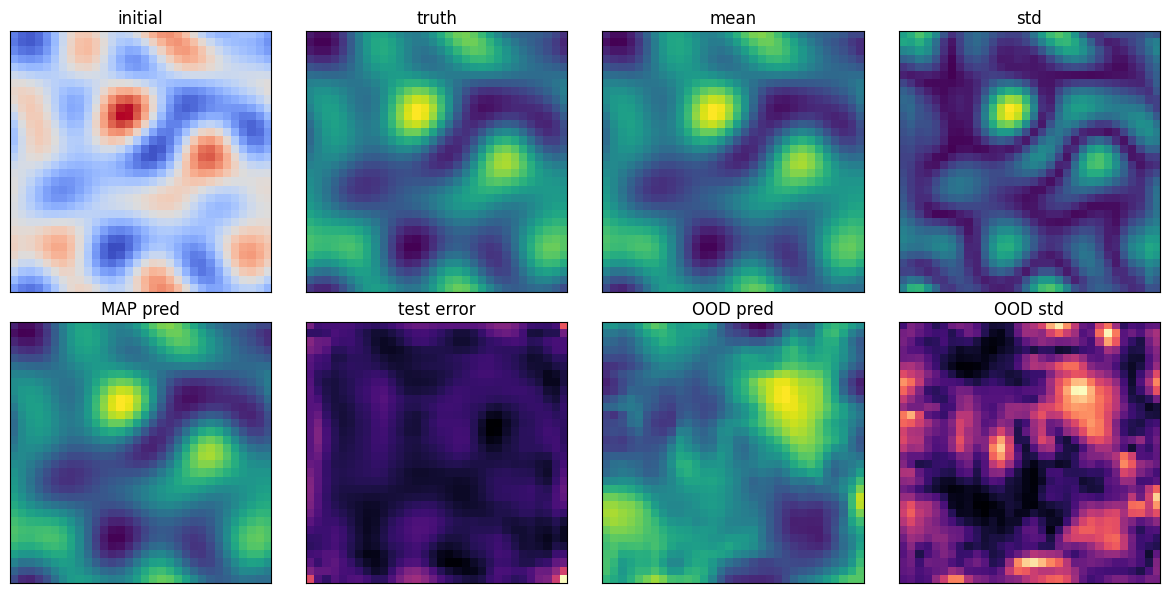

In [7]:
idx = 0
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
show_fields = [
    ('initial', test_x[idx, 0]),
    ('truth', test_y[idx, 0]),
    ('mean', uq_test.mean.cpu()[idx, 0]),
    ('std', uq_test.total_var.cpu()[idx, 0].sqrt()),
]
for ax, (title, field) in zip(axes[0], show_fields):
    ax.imshow(field, cmap='viridis' if title != 'initial' else 'coolwarm')
    ax.set_title(title)
for ax, field, title in zip(
    axes[1],
    [pred_test[idx, 0], pred_test[idx, 0] - test_y[idx, 0], pred_ood[idx, 0], uq_ood.total_var.cpu()[idx, 0].sqrt()],
    ['MAP pred', 'test error', 'OOD pred', 'OOD std'],
):
    ax.imshow(field, cmap='magma' if 'error' in title or 'std' in title else 'viridis')
    ax.set_title(title)
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


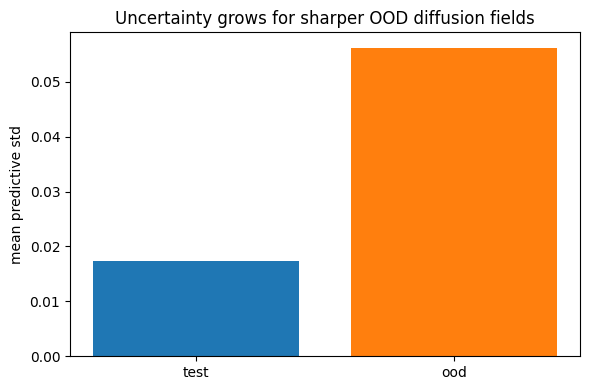

In [8]:
plt.figure(figsize=(6, 4))
plt.bar(['test', 'ood'], [uq_test.total_var.cpu().sqrt().mean().item(), uq_ood.total_var.cpu().sqrt().mean().item()], color=['tab:blue', 'tab:orange'])
plt.ylabel('mean predictive std')
plt.title('Uncertainty grows for sharper OOD diffusion fields')
plt.tight_layout()
plt.show()
